# Course 1 — Logistic Regression
================================

Logistic regression is a classification algorithm used to predict a discrete outcome, most commonly binary classification (predicting whether an input belongs to class $1$ or class $0$).

### In this notebook, we will explore:
1. **Sigmoid Activation Function**: Mapping real numbers to the probability range $(0, 1)$.
2. **Binary Classification with Scikit-Learn**: Fitting a classifier, evaluating it, and plotting the decision boundary.
3. **Logistic Regression from Scratch**: Coding the binary cross-entropy loss and gradient descent optimizer.
4. **Multiclass Classification (One-vs-Rest)**: Scaling binary classification to handle three or more categories.

In [ ]:
import sys
from pathlib import Path
# Add repository root to sys.path dynamically
project_root = Path(".").resolve()
while project_root.name and not (project_root / "utils").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from utils.helpers import make_logistic_data, plot_decision_boundary


## 1. Sigmoid Function

The sigmoid function, also known as the logistic function, maps any input value $z$ to a probability between $0$ and $1$:
$$g(z) = \frac{1}{1 + e^{-z}}$$

This function introduces non-linearity and forms the basis of logistic regression predictions:
- If $z \gg 0$, $g(z) \rightarrow 1$.
- If $z \ll 0$, $g(z) \rightarrow 0$.
- If $z = 0$, $g(z) = 0.5$.

In [16]:
def sigmoid(z):
    """Sigmoid activation: g(z) = 1 / (1 + e^{-z})"""
    return 1 / (1 + np.exp(-z))

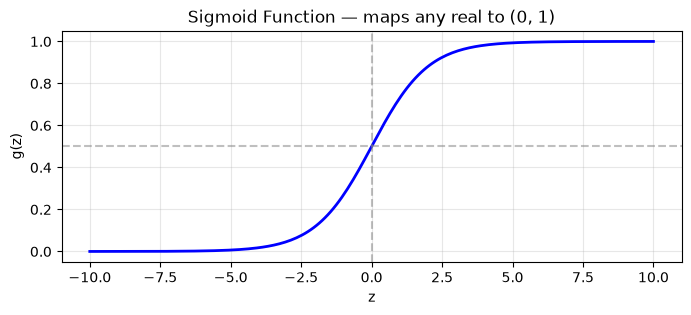

In [17]:
# Visualisation
z_vals = np.linspace(-10, 10, 200)
plt.figure(figsize=(8, 3))
plt.plot(z_vals, sigmoid(z_vals), "b-", linewidth=2)
plt.axhline(0.5, color="gray", ls="--", alpha=0.5)
plt.axvline(0, color="gray", ls="--", alpha=0.5)
plt.xlabel("z")
plt.ylabel("g(z)")
plt.title("Sigmoid Function — maps any real to (0, 1)")
plt.grid(alpha=0.3)
plt.show()

## 2. Binary Classification with Scikit-Learn

We train a Scikit-Learn `LogisticRegression` model on synthetic classification data. The threshold for dividing classes is standardly set at $P(y=1|x) = 0.5$ (or $z = w \cdot x + b = 0$).

Accuracy:          0.980
Coefficients:      [[1.94933908 2.06397091]]
Intercept:         [-13.5157289]

Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.96      0.98        27
     Class 1       0.96      1.00      0.98        23

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



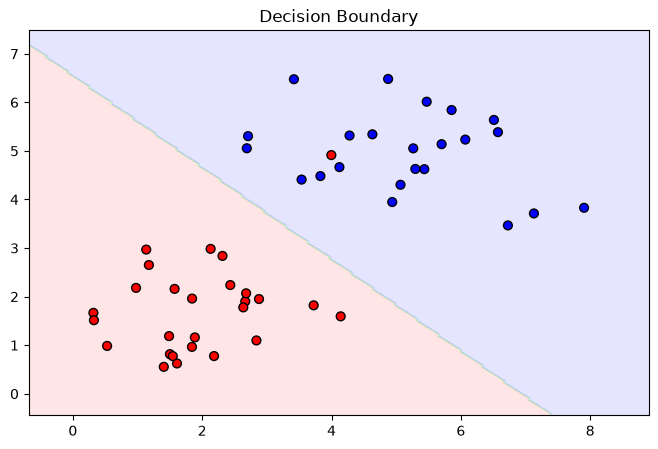

In [18]:
# ── Binary Classification ─────────────────────────────────────────────

X, y = make_logistic_data(n=200)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy:          {accuracy_score(y_test, y_pred):.3f}")
print(f"Coefficients:      {model.coef_}")
print(f"Intercept:         {model.intercept_}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])}")

plot_decision_boundary(model, X_test, y_test)

## 3. Logistic Regression from Scratch

### Cost Function: Binary Cross-Entropy Loss
In classification, Mean Squared Error leads to a non-convex surface with many local minima. Instead, we use **Binary Cross-Entropy Loss**:
$$J(w, b) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log(f(x^{(i)})) + (1 - y^{(i)}) \log(1 - f(x^{(i)})) \right]$$
where $f(x^{(i)}) = g(w \cdot x^{(i)} + b)$ is the model's prediction probability.

### Gradient Descent Updates
Though the prediction function is different, taking the partial derivatives of $J(w, b)$ results in the exact same update formulas as linear regression:
$$w_j := w_j - \alpha \frac{1}{m} \sum_{i=1}^m (f(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$
$$b := b - \alpha \frac{1}{m} \sum_{i=1}^m (f(x^{(i)}) - y^{(i)})$$

In [19]:
# ── Logistic Regression from Scratch ──────────────────────────────────

print("\n── Logistic Regression from Scratch ──")

def compute_loss(X, y, w, b):
    """Binary cross-entropy loss."""
    m = X.shape[0]
    z = X @ w + b
    f = sigmoid(z)
    return -(1 / m) * np.sum(y * np.log(f + 1e-8) + (1 - y) * np.log(1 - f + 1e-8))


def train_logistic(X, y, alpha=0.1, n_iters=5000):
    """Gradient descent for logistic regression."""
    m, n = X.shape
    w, b = np.zeros(n), 0.0
    losses = []
    for i in range(n_iters):
        z = X @ w + b
        f = sigmoid(z)
        error = f - y
        dw = (1 / m) * (X.T @ error)
        db = (1 / m) * np.sum(error)
        w -= alpha * dw
        b -= alpha * db
        if i % 500 == 0:
            losses.append(compute_loss(X, y, w, b))
    return w, b, losses


── Logistic Regression from Scratch ──


In [20]:
w_scratch, b_scratch, losses = train_logistic(X_train, y_train)
# Predict with threshold 0.5
probs = sigmoid(X_test @ w_scratch + b_scratch)
y_pred_scratch = (probs >= 0.5).astype(int)
print(f"Scratch accuracy:  {accuracy_score(y_test, y_pred_scratch):.3f}")

Scratch accuracy:  0.980


## 4. Multiclass Classification (One-vs-Rest)

To classify inputs into three or more classes ($K > 2$), the **One-vs-Rest (OvR)** approach trains $K$ separate binary classifiers. Each classifier $k$ models the probability of belonging to class $k$ vs all other classes combined. The final prediction selects the class whose binary classifier outputs the highest probability.

In [21]:
# ── Multiclass (One-vs-Rest) ──────────────────────────────────────────

print("\n── Multiclass (OvR) ──")
from sklearn.datasets import make_classification

X_mc, y_mc = make_classification(n_samples=300, n_features=2,
                                  n_classes=3, n_clusters_per_class=1,
                                  n_redundant=0, random_state=42)
X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.25, random_state=42
)

ovr = LogisticRegression()
ovr.fit(X_mc_train, y_mc_train)
print(f"OvR accuracy:      {accuracy_score(y_mc_test, ovr.predict(X_mc_test)):.3f}")



── Multiclass (OvR) ──


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

## Key Takeaways

- **Sigmoid function**: Transforms any linear value $w^T x + b \in (-\infty, \infty)$ into a probability $p \in (0, 1)$.
- **Decision Boundary**: The boundary dividing predictions. For a probability threshold of $0.5$, this is where $w^T x + b = 0$.
- **Cross-Entropy Loss**: Formulates a convex cost surface for logistic regression. It heavily penalizes incorrect predictions made with high confidence.
- **Multiclass Strategy**:
  - **One-vs-Rest (OvR)**: Trains $K$ binary models.
  - **Softmax Regression**: A generalization that handles multiclass outcomes directly using a single model.
- **Performance Metrics**: Accuracy is useful, but precision, recall, confusion matrices, and F1-score provide a complete picture of performance on imbalanced classes.

In [ ]:
# ── Key Takeaways ─────────────────────────────────────────────────────
print("""
╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Sigmoid converts linear output to probability ∈ (0, 1)       ║
║ • Decision boundary: where P(y=1|x) = 0.5  →  z = 0           ║
║ • Cross-entropy loss penalises confident wrong predictions     ║
║ • Multiclass: One-vs-Rest (OvR) or Softmax (multinomial)       ║
║ • Always evaluate with Accuracy, Precision, Recall, F1         ║
╚════════════════════════════════════════════════════════════════╝
""")